<a href="https://colab.research.google.com/github/Ariely13/Tugas/blob/main/ArilMuhammadNurham(241061012)UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt

In [64]:
df = pd.read_excel('/content/data soal UTS.xlsx')

In [65]:
df.columns = ['Y', 'X1', 'X2', 'X3', 'X4']
print(df.head())

       Y  X1     X2     X3     X4
0  71.28   0  12.53  56.90  71.11
1  73.80   1  13.62  71.40  69.55
2  70.25   0  13.00  71.43  67.85
3  73.64   0  13.43  74.53  68.84
4  75.11   1  13.87  79.24  71.34


In [66]:
X = sm.add_constant(df[['X1', 'X2', 'X3', 'X4']])
model_asli = sm.OLS(df['Y'], X).fit()
print(model_asli.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     36.07
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           9.24e-05
Time:                        02:44:51   Log-Likelihood:                -16.957
No. Observations:                  12   AIC:                             43.91
Df Residuals:                       7   BIC:                             46.34
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.9539     30.443      0.918      0.3

In [67]:
X = df[['X1', 'X2', 'X3', 'X4']]
X = sm.add_constant(X)
y = df['Y']

## Interpretasi :
Hasilnya model regresi ini akurat dengan nilai R2 sebesar 0,963. yang berarti variabel X_1 hingga X_4 secara bersama-sama mampu menjelaskan variabel IPM Y sebesar 96,3%. Berdasarkan nilai p-value, variabel X_2, X_3, dan X_4 berpengaruh signifikan terhadap IPM karena nilainya lebih kecil dari 0,05, sedangkan variabel X_1 tidak memiliki pengaruh yang nyata. Secara keseluruhan, faktor pendidikan X_2 dan kesehatan X_4 merupakan pendorong utama yang paling kuat dan positif dalam meningkatkan nilai IPM menurut data tersebut.

<Figure size 640x480 with 0 Axes>

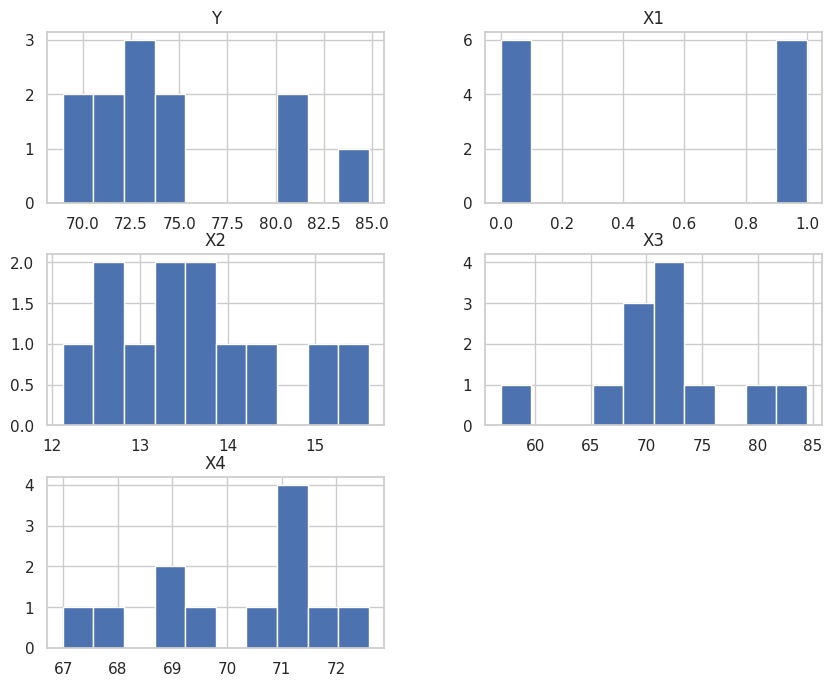

In [68]:
plt.suptitle("Distribusi Tiap Variabel")
df.hist(bins=10, figsize=(10, 8))
plt.show()


In [69]:
mean_data = df.mean()
std_data = df.std()
print('Rata-Rata')
print(mean_data)
print("Standar Deviasi")
print(std_data)

Rata-Rata
Y     74.698333
X1     0.500000
X2    13.636667
X3    71.340000
X4    70.198333
dtype: float64
Standar Deviasi
Y     4.827271
X1    0.522233
X2    1.039653
X3    6.721738
X4    1.715188
dtype: float64


In [70]:
np.random.seed(1)
df_sim = pd.DataFrame()
for col in ['Y', 'X1', 'X2', 'X3', 'X4']:
    df_sim[col] = np.random.normal(mean_data[col], std_data[col], 500)

In [71]:
#regresi data simulasi
X_sim = df_sim[['X1', 'X2', 'X3', 'X4']]
X_sim = sm.add_constant(X_sim)
Y_sim = df_sim['Y']

model_sim = sm.OLS(Y_sim, X_sim).fit()
print(model_sim.summary())

#perbandingan
print("R-Squared Data Asli:", model_asli.rsquared)
print("R-Squared Data Simulasi:", model_sim.rsquared)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.1790
Date:                Wed, 15 Apr 2026   Prob (F-statistic):              0.949
Time:                        02:44:52   Log-Likelihood:                -1490.4
No. Observations:                 500   AIC:                             2991.
Df Residuals:                     495   BIC:                             3012.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         71.7434      9.493      7.558      0.0

Perbandingan antara kedua model menunjukkan perbedaan yang sangat signifikan pada nilai koefisien determinasi. Data asli memiliki nilai r-squared sebesar 0.9634 yang berarti variabel independen memiliki hubungan yang sangat kuat dan nyata dalam mempengaruhi ipm. Sebaliknya, data hasil simulasi hanya memiliki nilai r-squared sebesar 0.0101 yang menunjukkan hampir tidak ada hubungan antara variabel tersebut. Hal ini terjadi karena data simulasi dibangkitkan secara acak sehingga hubungan atau korelasi antar variabel yang ada pada data asli menjadi hilang, meskipun nilai rata-rata dan standar deviasinya tetap sama.